# Week 5: Referral Attribution Lifecycle and Decision

**Business question:** How should Operations (Ops) review current referral-attribution evidence, and what workflow change should Product test next?

> Historical narrative notebook. It always runs the current shared JSON configuration rather than maintaining a separate copy of the matching logic. For Week 6 impact and multi-referrer process design, use `6.1_impact_and_process.ipynb`.


## 1. Accepted Rules

- Primary identity: exact `client + lead_id`
- Time gate: referral on or before `bookingDate`, with `booking_created_on` as fallback
- Selection: latest eligible prior referral
- Primary honored definition: `booking_source == "REFERRAL"`
- Reverse-time: Data Integrity only
- Tier C: separate identity-confirmation route
- Agreement value: transaction context only

In [1]:
# Locate the project and run the shared pipeline
# -> Read pipeline outputs only
# -> Do not duplicate matching or classification logic
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        path for path in [CURRENT_DIR, *CURRENT_DIR.parents]
        if (path / "config" / "attribution_rules.json").exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Cannot locate the project root from {CURRENT_DIR}. "
        "Run this notebook from the repository root or code folder."
    )

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from referral_attribution.pipeline import run_pipeline

result = run_pipeline(
    project_root=PROJECT_ROOT,
    write_outputs=True,
    verbose=False,
)
tables = result["tables"]

print(f"Project root detected: {PROJECT_ROOT.name}")
print("Pipeline completed and derived outputs were refreshed.")

Project root detected: Terra Softech_2
Pipeline completed and derived outputs were refreshed.


## 2. Data Controls

These controls protect the conclusion before any review rate is calculated. Test/demo rows are excluded, the strict booking-source rule is used consistently, and invalid chronology is never treated as bypass evidence.

In [2]:
# Display filter impact and the active regression contract
# -> Verify the analytical base
# -> Keep the accepted rule outcome visible
display(tables["filter_base_summary.csv"])

regression_table = pd.DataFrame(
    {
        "Metric": [
            "Eligible bookings",
            "Strict honored",
            "Primary review",
            "Tier A",
            "Tier B",
            "Tier C",
            "Reverse-time source disagreements",
        ],
        "Value": [
            result["regression"]["eligible_bookings"],
            result["regression"]["strict_honored"],
            result["regression"]["primary_review"],
            result["regression"]["tier_a"],
            result["regression"]["tier_b"],
            result["regression"]["tier_c"],
            result["regression"]["reverse_time_source_disagreement"],
        ],
    }
)
display(regression_table)

,dataset,before_filter,name_pattern_only_flagged,strong_signal_only_flagged,flagged_by_both,excluded_by_active_filter,after_filter
0,Referral submissions,5448,863,0,0,863,4585
1,Bookings,5275,557,5,5,562,4713


,Metric,Value
0,Eligible bookings,12
1,Strict honored,8
2,Primary review,4
3,Tier A,0
4,Tier B,4
5,Tier C,3
6,Reverse-time source disagreements,28


## 3. Lifecycle Funnel

The funnel includes an identity-overlap bridge because the first two stages use referral-enquiry grain while the later stages use booking grain. Rates must be read with the denominator printed in each row.

**Reading guide:** Identity overlap only shows that the same lead appears in both extracts. The dynamic insight below shows how the time-order gate reduces that population under the active configuration. Do not interpret the identity-overlap stage as a conversion or bypass rate.


In [3]:
# Display the funnel with explicit denominators
# -> Keep reverse-time outside the primary funnel
# -> Do not treat different grains as one conversion rate
funnel = tables["lifecycle_funnel_summary.csv"].assign(
    rate_display=lambda frame: frame["rate"].map(
    lambda value: "" if pd.isna(value) else f"{value:.1%}"
)
)
display(
    funnel[
        [
            "stage_order",
            "stage",
            "grain",
            "count",
            "denominator",
            "rate_display",
            "included_in_primary_funnel",
        ]
    ]
)

,stage_order,stage,grain,count,denominator,rate_display,included_in_primary_funnel
0,1,Referral submissions after test/demo filtering,Referral enquiry,4585,Filtered referral submissions,100.0%,True
1,2,Referral submissions sharing Exact client + le...,Referral enquiry,3149,Filtered referral submissions,68.7%,True
2,3,Bookings sharing Exact client + lead_id with a...,Booking,4062,Filtered bookings,86.2%,True
3,4,Bookings with at least one time-valid prior re...,Booking,12,Bookings sharing Exact client + lead_id,0.3%,True
4,5,Honored bookings: Booking source recorded as R...,Booking,8,Bookings with time-valid prior referral,66.7%,True
5,6,Primary review candidates,Booking,4,Bookings with time-valid prior referral,33.3%,True
6,7,Reverse-time source disagreements (outside fun...,Referral enquiry,28,Not a bypass denominator,,False


In [4]:
# Generate a dynamic funnel explanation
# -> Identify the largest drop caused by chronology
# -> Avoid reading identity overlap as conversion
funnel_counts = funnel.set_index("stage")["count"]
identity_bookings = int(
    funnel_counts["Bookings sharing Exact client + lead_id with a referral submission"]
)
eligible_bookings = int(
    funnel_counts["Bookings with at least one time-valid prior referral"]
)
strict_honored = int(funnel_counts["Honored bookings: Booking source recorded as REFERRAL"])
primary_review = int(funnel_counts["Primary review candidates"])

display(
    Markdown(
        f"""**Funnel insight:** {identity_bookings:,} bookings share client and lead identity
with a referral, but only {eligible_bookings:,} have a referral dated before the booking.
The largest analytical drop is therefore caused by chronology, not by the final source
classification. Among the time-valid bookings, {strict_honored} are strictly honored and
{primary_review} require primary review."""
    )
)

**Funnel insight:** 4,062 bookings share client and lead identity
with a referral, but only 12 have a referral dated before the booking.
The largest analytical drop is therefore caused by chronology, not by the final source
classification. Among the time-valid bookings, 8 are strictly honored and
4 require primary review.

## 4. Attribution Diagnostics

These tables show whether the primary result depends on project scope, source definition, multiple referrers, or the selected attribution window.

In [5]:
# Display decision-relevant sensitivity results
# -> Same versus cross project
# -> Multiple referrers and time windows
display(Markdown("### Same vs Cross Project"))
display(tables["same_vs_cross_project_summary.csv"])

display(Markdown("### Multiple Prior Referrers"))
display(tables["multi_referrer_summary.csv"])

display(Markdown("### Attribution Window Sensitivity"))
display(
    tables["attribution_window_sensitivity.csv"][
        [
            "attribution_window",
            "matched_bookings",
            "strict_honored_bookings",
            "primary_review_candidates",
        ]
    ]
)

### Same vs Cross Project

,project_relationship,matched_bookings,strict_honored_bookings,primary_review_candidates,share_of_eligible_bookings
0,Cross project,1,1,0,0.083333
1,Same project,11,7,4,0.916667


### Multiple Prior Referrers

,referrer_group,matched_bookings,strict_honored_bookings,median_prior_referrers,primary_review_candidates,share_of_eligible_bookings
0,Multiple prior referrers,5,1,134.0,4,0.416667
1,Single prior referrer,7,7,1.0,0,0.583333


### Attribution Window Sensitivity

,attribution_window,matched_bookings,strict_honored_bookings,primary_review_candidates
0,30 days,11,7,4
1,60 days,11,7,4
2,90 days,12,8,4
3,180 days,12,8,4
4,No limit,12,8,4


**Diagnostic insight:** The four primary review candidates remain under every tested window, so the review queue is not sensitive to the proposed 30/60/90/180-day cutoffs. All four candidates have multiple prior referrers and therefore remain Tier B. The strict booking-source definition is the single reporting rule; enquiry source remains visible only as review context.

## 5. Ops Review Board

The board is a single sortable queue, but the classes are not interchangeable:

- **P0:** reverse-time data repair
- **P1:** primary attribution review
- **P2:** secondary identity confirmation

In [6]:
# Summarize the Ops queue
# -> Show workload by case class
# -> Display compact fields for direct review
ops_board = tables["ops_review_board.csv"]
ops_summary = (
    ops_board.groupby(
        ["priority_order", "priority", "case_class", "confidence_tier"],
        dropna=False,
    )
    .size()
    .rename("case_count")
    .reset_index()
    .sort_values("priority_order")
)
display(ops_summary)

display(
    ops_board[
        [
            "case_id",
            "priority",
            "case_class",
            "booking_id",
            "referral_enquiry_id",
            "review_reason",
            "recommended_action",
        ]
    ].head(12)
)

,priority_order,priority,case_class,confidence_tier,case_count
0,0,P0 - Repair chronology,Reverse-time data integrity,Data Integrity,28
1,1,P1 - Verify attribution,Primary attribution review,Tier B - Ambiguous attribution review,4
2,2,P2 - Confirm identity,Secondary identity review,Tier C - Secondary identity review,3


,case_id,priority,case_class,booking_id,referral_enquiry_id,review_reason,recommended_action
0,INTEGRITY-6870,P0 - Repair chronology,Reverse-time data integrity,3765,6870,Booking date is earlier than referral submissi...,"Validate referral and booking timestamps, then..."
1,INTEGRITY-6872,P0 - Repair chronology,Reverse-time data integrity,3766,6872,Booking date is earlier than referral submissi...,"Validate referral and booking timestamps, then..."
2,INTEGRITY-6874,P0 - Repair chronology,Reverse-time data integrity,3767,6874,Booking date is earlier than referral submissi...,"Validate referral and booking timestamps, then..."
3,INTEGRITY-6876,P0 - Repair chronology,Reverse-time data integrity,3768,6876,Booking date is earlier than referral submissi...,"Validate referral and booking timestamps, then..."
4,INTEGRITY-6878,P0 - Repair chronology,Reverse-time data integrity,3769,6878,Booking date is earlier than referral submissi...,"Validate referral and booking timestamps, then..."
5,INTEGRITY-6880,P0 - Repair chronology,Reverse-time data integrity,3770,6880,Booking date is earlier than referral submissi...,"Validate referral and booking timestamps, then..."
6,INTEGRITY-6882,P0 - Repair chronology,Reverse-time data integrity,3771,6882,Booking date is earlier than referral submissi...,"Validate referral and booking timestamps, then..."
7,INTEGRITY-7739,P0 - Repair chronology,Reverse-time data integrity,4230,7739,Booking date is earlier than referral submissi...,"Validate referral and booking timestamps, then..."
8,INTEGRITY-7741,P0 - Repair chronology,Reverse-time data integrity,4231,7741,Booking date is earlier than referral submissi...,"Validate referral and booking timestamps, then..."
9,INTEGRITY-7743,P0 - Repair chronology,Reverse-time data integrity,4232,7743,Booking date is earlier than referral submissi...,"Validate referral and booking timestamps, then..."


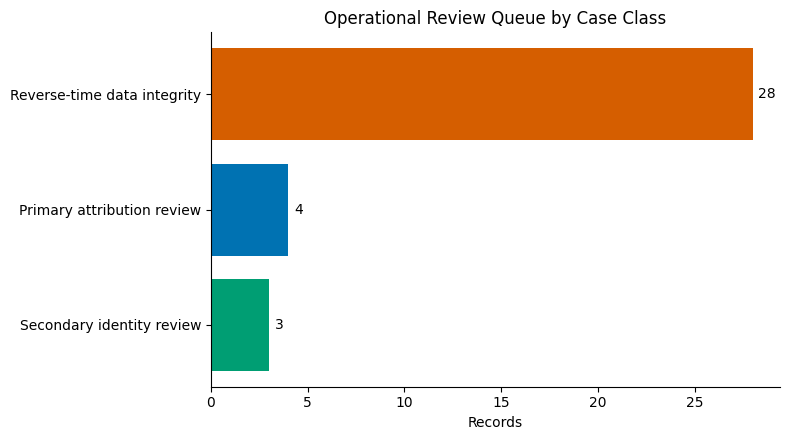

In [7]:
# Plot the three independent work queues
# -> Do not combine them into a bypass count
plot_data = ops_summary.sort_values("priority_order")
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#D55E00", "#0072B2", "#009E73"]
bars = ax.barh(plot_data["case_class"], plot_data["case_count"], color=colors)
ax.invert_yaxis()
ax.set_title("Operational Review Queue by Case Class")
ax.set_xlabel("Records")
ax.set_ylabel("")
ax.bar_label(bars, padding=4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Recommendation

**Ops this week**

1. Repair or explain the 28 reverse-time records.
2. Verify ownership and source for the four Tier B bookings.
3. Confirm identity for the three Tier C records before attribution review.

**One Product workflow change**

Test a proposed 30-day referral-history warning when a booking is saved with a non-referral source. Show the latest prior referral and all prior referrers, require an owner or override reason, and route multi-referrer cases to manual review. Keep unlimited-window analysis as a sensitivity view until the business owner approves a formal window.

**Data repair**

Track timestamp provenance, source-change history, and override reason. Use the strict booking-source metric for attribution reporting, and monitor enquiry/booking source disagreements separately as data-quality evidence.

## 7. Measurement Plan

| Horizon | Leading indicator | Guardrail | Falsifier |
|---|---|---|---|
| 30 days | Non-referral bookings checked before confirmation; open P0/P1 age | Booking completion time and override volume | Most warnings are correct non-referral bookings or cannot identify an owner |
| 60 days | Warnings resolved before booking completion | Manual-review backlog and false escalation | Queue grows without better source accuracy |
| 90 days | Strict honored rate among time-valid eligible bookings | Missing timestamps and source disagreement | Attribution quality does not improve after repair and workflow checks |

## 8. Limitations

- Review candidates are not proof of fraud, bypass, or commission loss.
- Multiple prior referrers prevent automatic ownership assignment.
- Agreement value is not commission impact.
- Test/demo filtering uses configured name patterns and explicit strong signals.
- Exact encrypted mobile/email equality requires identity confirmation.
- The 30-day workflow check is proposed, not an approved business policy.